In [2]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

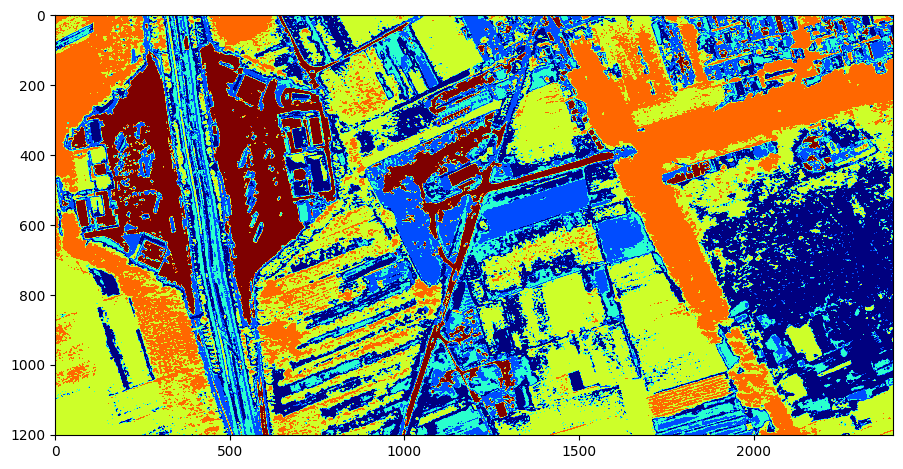

In [23]:
#creating a function to convert original img to numpy array

img = np.array(Image.open('/Users/sinner/Desktop/Waste_Images_All/0802.jpg'))
height, width, band_n = img.shape

X = img.reshape(-1, band_n)

#define the no. of output classes
class_n = 6

k_means = KMeans(n_clusters=class_n, n_init=5)
k_means.fit(X)

#get classified result and reshape it to an image
X_classified = k_means.labels_
result = X_classified.reshape(height,width)

#display the original image with classification
plt.figure(figsize=(12,12))
cmap = plt.get_cmap('jet', np.max(result)-np.min(result)+1)



In [1]:
# #display og image
# plt.subplot(211)
# plt.imshow(X.reshape(height,width,3))
#
# #display classification result
# plt.subplot(212)
# plt.imshow(result, cmap = cmap)

In [22]:
input_img_path = '/Users/sinner/Desktop/For_Clustering/0255.jpg'
output_folder_path = '/Users/sinner/PycharmProjects/SML_Project/FINAL_FILES/USL_Clustering_Package/Segmentation_Output/Sample_10'


img = np.array(Image.open(input_img_path))
height, width, band_n = img.shape

plt.imsave(os.path.join(output_folder_path, 'Original.jpg'), img)

X = img.reshape(-1, band_n)

for n_clusters in range(2, 9):

    k_means = KMeans(n_clusters=n_clusters, n_init=5)
    k_means.fit(X)

    #get classified result and reshape it to an image
    X_classified = k_means.labels_
    result = X_classified.reshape(height, width)

    cmap = plt.get_cmap('jet', np.max(result)-np.min(result)+1)

    plt.imsave(os.path.join(output_folder_path, f'{n_clusters}.jpg'), result, cmap=cmap)